Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


/Users/aidanbehmer/Sum25Research/InferenceMultiFidelity/lf_sobol2p_n['dtau0', 'ns']
<KeysViewHDF5 ['flux_vectors', 'kfkms', 'params', 'zout']>
(200, 13, 35)
[4.6 4.4 4.2 4.  3.8 3.6 3.4 3.2 3.  2.8 2.6 2.4 2.2]
[False False False False False False False False False False False False
 False]
Closest index to z=3.6 is at index 5, zout=3.5999999999999996
[[0.001084 0.001626 0.002168 ... 0.018428 0.01897  0.019512]
 [0.001084 0.001626 0.002168 ... 0.018428 0.01897  0.019512]
 [0.001084 0.001626 0.002168 ... 0.018428 0.01897  0.019512]
 ...
 [0.001084 0.001626 0.002168 ... 0.018428 0.01897  0.019512]
 [0.001084 0.001626 0.002168 ... 0.018428 0.01897  0.019512]
 [0.001084 0.001626 0.002168 ... 0.018428 0.01897  0.019512]]
mean_flux_low: 0.10938407037564798
std_flux_low: 0.00718393820209894
X_param shape: (7000, 3)
X_k shape: (7000, 1)
X_param column 0 normalized: min=-0.3991583066992462, max=0.2474132375791669
X_param column 1 normalized: min=1.2085470654070378e-09, max=2.596622860059142e-09

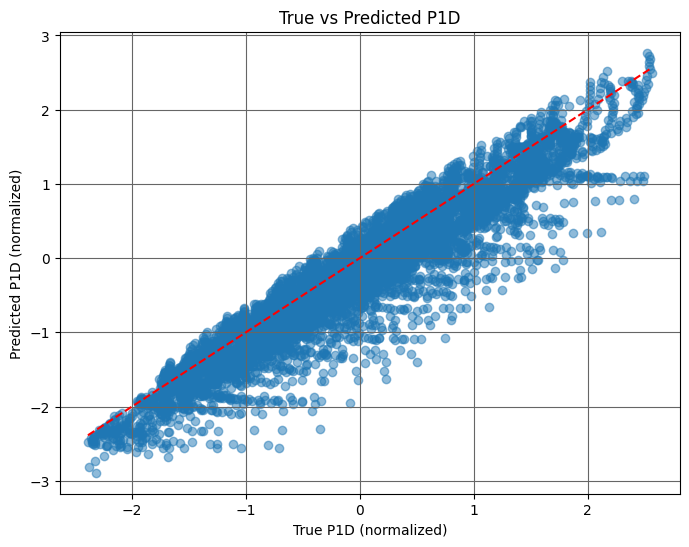

In [1]:
import numpy as np


class PySREmu:

    # because we normalized to [0, 1]
    dtau0_fid = 0.5
    Ap_fid = 0.5
    ns_fid = 0.5

    def equation_(self, dtau0, Ap, ns, x1, x2):
        """
        x1: normalized k
        x2: resoltuion (LF: 0.4, HF: 0.8)

        return: normalized P1D

        separate terms of parameter-dependent parts and the global parts (inlcudes x1 and x2)

        equation(Herei, alphaq, x1, x2)
         = equation1(Herei, x1, x2) - equation1(Herei_fid, x1, x2) + equation2(alphaq, x1, x2) - equation2(alphaq_fid, x1, x2)
          + Mean(constant terms(eqaution1(Herei_fid, x1, x2) and equation2(alphaq_fid, x1, x2) are constants))
        """
        return (
            self.equation1(dtau0, x1, x2)
            - self.equation1(self.dtau0_fid, x1, x2)
            + self.equation2(Ap, x1, x2)
            - self.equation2(self.Ap_fid, x1, x2)
            + 0.0
            + self.equation3(ns, x1, x2)
            - self.equation3(self.ns_fid, x1, x2)
        ) + np.mean(
            [
                self.equation1(self.dtau0_fid, x1, x2),
                self.equation2(self.Ap_fid, x1, x2),
                self.equation3(self.ns_fid, x1, x2),
            ]
        )  # Mean of constant terms

    def equation1(self, dtau0, x1, x2):
        """
        only vary dtau0
        """
        return  (((dtau0 + x1) - 1.0002773) * 1.6420794) - x2


    def equation2(self, Ap, x1, x2):
        """
        only vary Ap
        """
        return ((((Ap * (x1 * x1)) + -1.17207) * ((Ap * -2.4086287) + x2)) - 1.0434937) - (x1 * -1.5642396)

    
    def equation3(self, ns, x1, x2):
        """
        only vary ns
        """
        return (-0.48247418 + ((x1 * (ns * 3.1947596)) - x2)) - x1

    def predict(self, X):
        """
        X: (number of points, number of parameters) -> e.g., (1750, 5)

        0: dtau0
        1: Ap
        2: ns
        3: x1
        4: x2
        """
        y_pred = []

        for _x in X:
            # _x is (4, )
            dtau0, Ap, ns, x1, x2 = _x
            this_y_pred = self.equation_(dtau0, Ap, ns, x1, x2)
            y_pred.append(this_y_pred)

        return np.array(y_pred)



#### NOW STARTS THE REST OF THE CODE ####


import time

import matplotlib.pyplot as plt
from typing import List
import pysr
import h5py
import sympy
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split



# Configure plot defaults
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["grid.color"] = "#666666"

####### Set Input Arguments ########
# This is where you set the args to your function.

# take z = 3.6
z = 3.6

# Plotting
quantile_low = 0.16  # quantile for parameter value to fix
quantile_high = 0.84  # quantile for parameter value to fix
####################################

param_dict = {
    "dtau0": 0,
    "tau0": 1,
    "ns": 2,
    "Ap": 3,
    "herei": 4,
    "heref": 5,
    "alphaq": 6,
    "hub": 7,
    "omegamh2": 8,
    "hireionz": 9,
    "bhfeedback": 10,
}
# param_idx = param_dict[param_name]  # index of the parameter in the params array
param_subset=["dtau0","Ap","ns"]
param_subset_name = "-".join(param_subset) # make list into string
outdir = "3pvar"

import os
print(os.path.abspath("lf_sobol2p_n['dtau0', 'ns']"))

# TODO: Probably also be careful about the filepath~
with h5py.File(
    f"{outdir}/lf_sobol2p_n{param_subset_name}.hdf5", "r"
) as file:
    print(file.keys())
    
    flux_vectors_low = file["flux_vectors"][:]
    kfkms_low = file["kfkms"][:]
    # kfmpc = file["kfmpc"][:]
    zout = file["zout"][:]
    
    nnparam, nzz, nkk = kfkms_low.shape

    # this is a flatten array of param and k
    resolution_low=np.full((nnparam * nkk, 1),0.4)
    # TODO: high fidelity resolution

    print(kfkms_low.shape)
    params_low = file["params"][:]
    print(zout)
    print(zout==z)
    # closest index z to zout
    zindex = np.argmin(np.abs(zout - z))
    print("Closest index to z={} is at index {}, zout={}".format(z, zindex, zout[zindex]))
    # difference should be small such that |z- zout| < 0.1
    assert np.abs(zout[zindex] - z) < 0.1
    print(kfkms_low[:, zindex, :])
    
# TODO load high-fidelity data
    
#kfkms.shape, flux_vectors.shape, zout.shape, params.shape
"""
with h5py.File(
    "../InferenceMultiFidelity/1pvar/hf_{}_npoints50_datacorrFalse.hdf5".format(param_name), "r"
) as file:
    print(file.keys())

    flux_vectors_hi = file["flux_vectors"][:]
    kfkms_hi = file["kfkms"][:]
    # kfmpc = file["kfmpc"][:]
    zout_hi = file["zout"][:]
    resolution_hi=np.full((1750,1),0.8)
    params_hi = file["params"][:]
"""
# zindex = np.where(zout == z)[0]#[0]  # index of z = 5

# take z=3.6, and flatten the flux vectors, such that the dim=1 is p1d values per k and parameter
flux_vectors_z_low = flux_vectors_low[:, zindex, :]
mean_flux_low = np.mean(flux_vectors_z_low, axis=0)
std_flux_low = np.std(flux_vectors_z_low, axis=0)
flux_vectors_z_low = (flux_vectors_z_low - mean_flux_low) / std_flux_low  # normalize to mean

# save the mean and std txt files for later use
np.savetxt(f"{outdir}/mean_flux_low_{param_subset_name}.txt", mean_flux_low)
np.savetxt(f"{outdir}/std_flux_low_{param_subset_name}.txt", std_flux_low)

print("mean_flux_low:", mean_flux_low.mean())
print("std_flux_low:", std_flux_low.mean())
#use the mean and std variables later when reverting back to original scale
#make this a function instead of in here
########################################################################
flux_vectors_z_low = flux_vectors_z_low.flatten()[:, np.newaxis]  # add a new axis to make it 2D

# do the same for kfkms
kfkms_z_low = kfkms_low[:, zindex, :]
kfkms_z_low = kfkms_z_low.flatten()[:, np.newaxis]  # add a new axis to make it 2D

# loop over param_subset to get the values for each parameter
X_param = []
for param_test in param_subset:
    # get the index from the dict
    param_idx = param_dict[param_test]
    # get the values for this parameter
    params_values_low = params_low[:, param_idx]

    # repeat this for the number of kfkms
    params_values_low = np.repeat(params_values_low[:, np.newaxis], kfkms_low.shape[2], axis=1)
    params_values_low = params_values_low.flatten()[:, np.newaxis]  # add a new axis to make it 2D

    # append to the list
    X_param.append(params_values_low)

# Shapes: (1750, 1)
X_param = np.hstack(X_param)
print("X_param shape: "+str(X_param.shape))
X_k = kfkms_z_low
print("X_k shape: "+str(X_k.shape))
y = flux_vectors_z_low

assert(y.shape == (nnparam * nkk, 1))
# Concatenate inputs to form design matrix

# normalization of x
X_param_normalized = np.copy(X_param)
for i in range(X_param.shape[1]):
    X_param_normalized[:, i] = (X_param[:, i] - np.min(X_param[:, i])) / (np.max(X_param[:, i]) - np.min(X_param[:, i]))
    print(f"X_param column {i} normalized: min={np.min(X_param[:, i])}, max={np.max(X_param[:, i])}")

#save the max and min for use in reverting back to original scale
#make this a function as well

X_k_max=np.max(X_k,axis=0)
X_k_min=np.min(X_k,axis=0)
X_k_normalized=(X_k-X_k_min)/(X_k_max-X_k_min)

print(X_param_normalized.shape)
print(X_k_normalized.shape)
print(resolution_low.shape)

X = np.hstack([X_param_normalized, X_k_normalized])  # shape: (1750, 2)
X_1 = np.hstack([X_param_normalized, X_k_normalized,resolution_low])  # shape: (1750, 4)
# TODO : add resolution_high when using high-fidelity data
assert(X.shape== (nnparam * nkk, 4))

# --- Preparing the input to the model ---
X_test = X_1  # only low-fidelity data for testing
# TODO : add high-fidelity data for testing later
y_true = y  # true values for comparison
# TODO: add high-fidelity true values for comparison later
# y_hi = flux_vectors_z_high

# --- Predict using your trained model ---
model = PySREmu()
y_pred = model.predict(X_test)
print("y_pred shape: "+str(y_pred.shape))
# difference between true and predicted
y_diff = y_true.flatten() - y_pred.flatten()
# RMSE
rmse = np.sqrt(np.mean(y_diff**2))
print("RMSE: "+str(rmse))
# relative error
relative_error = np.mean(np.abs(y_diff / y_true.flatten())) * 100
print("Relative Error (%): "+str(relative_error))
# prediction plot
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([np.min(y_true), np.max(y_true)], [np.min(y_true), np.max(y_true)], 'r--')
plt.xlabel("True P1D (normalized)")
plt.ylabel("Predicted P1D (normalized)")
plt.title("True vs Predicted P1D")
plt.grid()
# plt.savefig(f"{outdir}/lf_true_vs_predicted_p1d_{param_subset_name}_z{z}.pdf",dpi=300)
# plt.show()


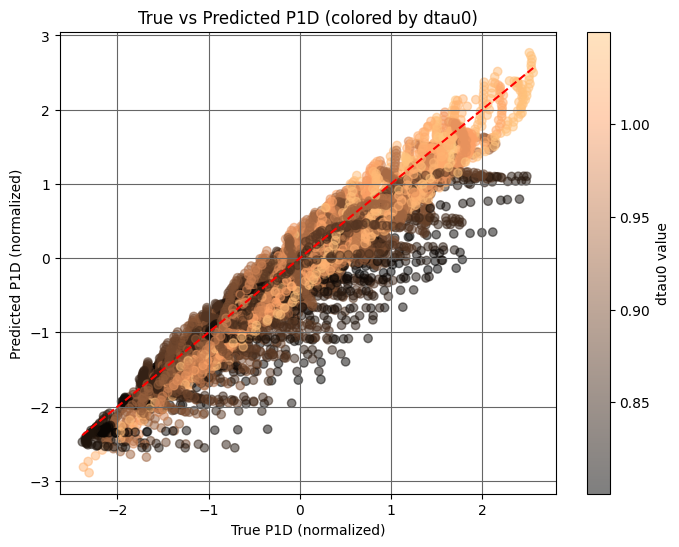

RMSE: 0.0021602003684659692
Relative Error (%): 2.0698218658921523


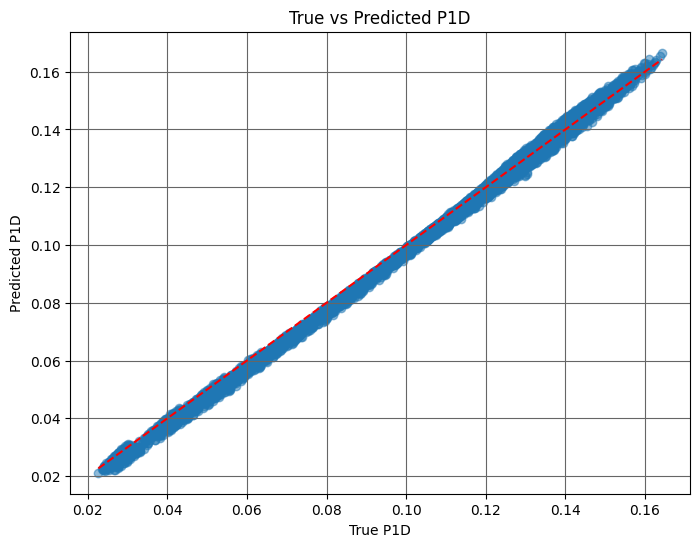

In [2]:


# TODO: remove this later for clean
n_sims, n_k = nnparam, nkk

mean_flux_expand = np.repeat(mean_flux_low[np.newaxis, :], n_sims, axis=0)
std_flux_expand = np.repeat(std_flux_low[np.newaxis, :], n_sims, axis=0)

# Flatten to align with y_pred
mean_flux_flat = mean_flux_expand.flatten()
std_flux_flat = std_flux_expand.flatten()

# Denormalize
y_pred_denorm = y_pred.flatten() * std_flux_flat + mean_flux_flat

# comparing true vs predicted

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    y_true.flatten(), y_pred.flatten(),
    c=X_param[:, 2],  # color by dtau0
    cmap='copper', alpha=0.5
)
plt.plot([np.min(y_true), np.max(y_true)], [np.min(y_true), np.max(y_true)], 'r--')
plt.xlabel("True P1D (normalized)")
plt.ylabel("Predicted P1D (normalized)")
plt.title("True vs Predicted P1D (colored by dtau0)")
plt.colorbar(sc, label="dtau0 value")
plt.grid(True)
# plt.savefig(f"{outdir}/lf_true_vs_predicted_p1d_colored_dtau0_{param_subset_name}_z{z}.pdf",dpi=300)

plt.show()


#normalized plot
# TODO: remove this later for clean
n_sims, n_k = nnparam, nkk

mean_flux_expand = np.repeat(mean_flux_low[np.newaxis, :], n_sims, axis=0)
std_flux_expand = np.repeat(std_flux_low[np.newaxis, :], n_sims, axis=0)

# Flatten to align with y_pred
mean_flux_flat = mean_flux_expand.flatten()
std_flux_flat = std_flux_expand.flatten()

# Denormalize
y_pred_denorm = y_pred.flatten() * std_flux_flat + mean_flux_flat

y_true_denorm = y_true.flatten() * std_flux_flat + mean_flux_flat

y_diff_denorm = y_true_denorm.flatten() - y_pred_denorm.flatten()
# RMSE
rmse_denorm = np.sqrt(np.mean(y_diff_denorm**2))
print("RMSE: "+str(rmse_denorm))
# relative error
relative_error_denorm = np.mean(np.abs(y_diff_denorm / y_true_denorm.flatten())) * 100
print("Relative Error (%): "+str(relative_error_denorm))


plt.figure(figsize=(8, 6))
plt.scatter(y_true_denorm, y_pred_denorm, alpha=0.5)
plt.plot([np.min(y_true_denorm), np.max(y_true_denorm)], [np.min(y_true_denorm), np.max(y_true_denorm)], 'r--')
plt.xlabel("True P1D")
plt.ylabel("Predicted P1D")
plt.title("True vs Predicted P1D")
plt.grid()
# plt.savefig(f"{outdir}/lf_true_vs_predicted_p1d_denorm_{param_subset_name}_z{z}.pdf",dpi=300)
plt.show()

In [8]:
nnparam, nkk, params_low.shape

(200, 35, (200, 15))

In [ ]:
X_param.shape, relative_error_denorm.shape, y_pred.shape, X_param_normalized.shape

((7000, 3), (), (7000,), (7000, 3))

In [23]:
relative_error_denorm_array = np.mean(np.abs(y_diff_denorm.reshape((nnparam, nkk)) / y_true_denorm.reshape((nnparam, nkk))), axis=0) * 100
relative_error_denorm_array.shape

(35,)

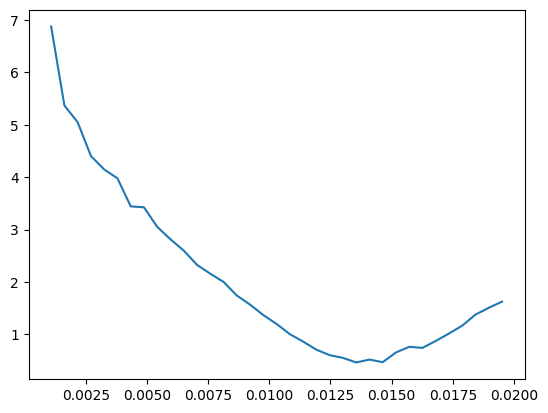

In [30]:
plt.plot(kfkms_low[0, 0, :], relative_error_denorm_array)

In [13]:
relative_error_array = y_pred.reshape((nnparam, nkk)) / y_true.reshape((nnparam, nkk)) - 1
dtau_array = X_param[:, 0].reshape((nnparam, nkk))
Ap_array = X_param[:, 1].reshape((nnparam, nkk))
np_array = X_param[:, 2].reshape((nnparam, nkk))

relative_error_array.shape, Ap_array.shape

((200, 35), (200, 35))

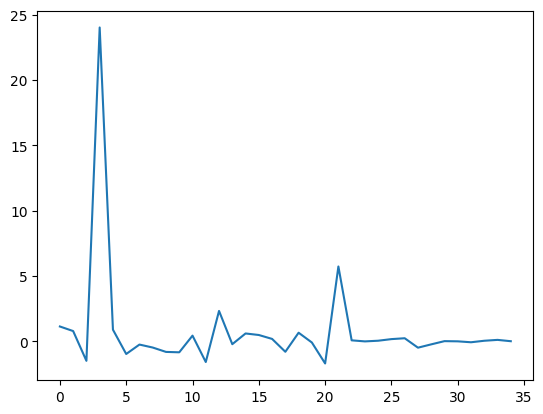

In [20]:
plt.plot(relative_error_array.mean(axis=0))

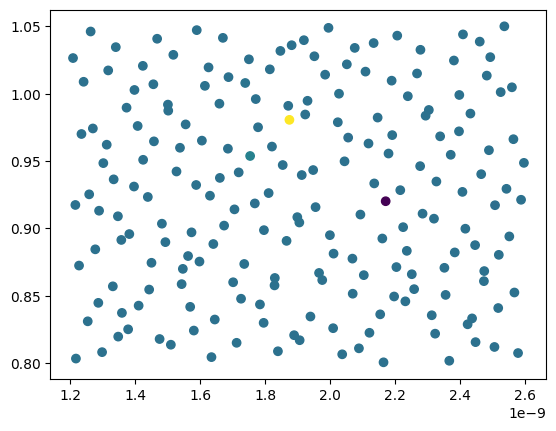

In [17]:
relative_error_array_norm = (
    relative_error_array.mean(axis=1) - np.min(relative_error_array.mean(axis=1))) / (
        np.max(relative_error_array.mean(axis=1)) - np.min(relative_error_array.mean(axis=1)
    )
)

plt.scatter(
    Ap_array[:, 0], np_array[:, 0],
    c=relative_error_array_norm,
    cmap="viridis"
)

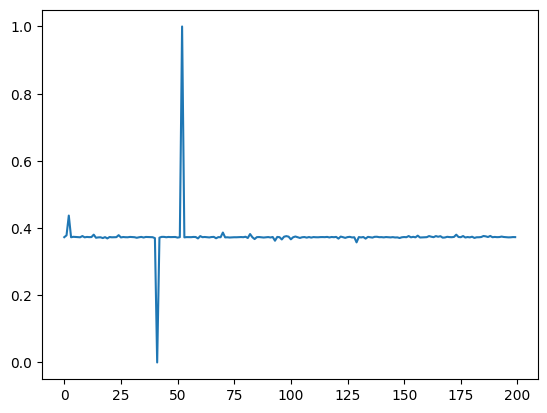

In [19]:
plt.plot(relative_error_array_norm)